In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from tavily import TavilyClient
import os
import re

In [1]:
!npm install -g @marp-team/marp-cli


added 153 packages in 14s

18 packages are looking for funding
  run `npm fund` for details


npm warn deprecated mathjax-full@3.2.2: Version 4 replaces this package with the scoped package @mathjax/src


In [2]:
GEMINI_MODEL = 'gemini-2.5-flash'
GEMINI_API_KEY = os.getenv('GEMINI_TOKEN')

model = ChatGoogleGenerativeAI(
    model=GEMINI_MODEL,
    api_key=GEMINI_API_KEY,
    temperature=0.3, 
    max_tokens=None,
    timeout=None,
    max_retries=2,
)

In [6]:
from typing import List
import operator
from pydantic import BaseModel


class PlanStep(BaseModel):
    title: str
    concept: str

    
class Plan(BaseModel):
    steps: List[PlanStep]

    
class AgentState(TypedDict):
    task: str                         
    plan: List[PlanStep]
    slides_md: Annotated[List[str], operator.add] 
    html_path: str                     

In [3]:
import requests
access_key = os.getenv('UNSPLASH_ACCESS_KEY')
from langchain.tools import tool

def get_unsplash_image(query: str):
    "Recupera la url di una foto da Unsplash"
    
    url = "https://api.unsplash.com/search/photos"
    
    params = {
        "query": query,
        "per_page": 1,
        "orientation": "landscape",
        "client_id": access_key
    }
    
    response = requests.get(url, params=params)
    if response.status_code == 200:
        data = response.json()
        if data["results"]:
            # Usiamo la versione 'regular' o 'small' per non appesantire le slide
            return data["results"][0]["urls"]["regular"]
    
    # Fallback se non trova nulla
    return "https://picsum.photos/800/600"

'https://images.unsplash.com/photo-1669897965746-b2758d6ee3db?crop=entropy&cs=tinysrgb&fit=max&fm=jpg&ixid=M3w5MjgzNzh8MHwxfHNlYXJjaHwxfHxkb2clMjB3aXRoJTIwYm9uZXxlbnwwfDB8fHwxNzc2OTU5NTI1fDA&ixlib=rb-4.1.0&q=80&w=1080'

In [7]:
import subprocess
def planner_node(state: AgentState):
    """Il Planner decide la struttura della lezione."""
    prompt = f"""Analizza la richiesta: '{state['task']}'.
    Pianifica N slide didattiche. Per ogni slide restituisci solo titolo e concetto in formato json"""
    
    
    plan = model.with_structured_output(Plan).invoke(prompt)
    print(plan)
    
    return {"plan": plan}


def slider_writer_node(state: AgentState):
    """L'Executor scrive il MD"""
    current_slide = state["plan"].steps[0]
    print(current_slide)
    # Generazione contenuto Markdown
    prompt = f"""Scrivi il contenuto di una **UNICA** slide Marp senza aggiungere il delimitatore ```marp e senza aggiungere tag html
    Titolo: {current_slide.title}
    Concetto: {current_slide.concept}
    
    Regole:
    1. Usa la sintassi Marp.
    2. Usa placeholder come $img_1(descrizione immagine) per le immagini.
    3. Quando crei elenchi puntati, usa la sintassi dei frammenti di Marp * ( ) per far apparire i punti uno alla volta durante la presentazione.
    Esempio:
    # {current_slide.title}
    - Punto 1
    - Punto 2
    ![bg right:30%]($img_1(un vulcano in eruzione visto dall'alto))
    """
    result = model.invoke(prompt)
    content = result.content
    # Estraiamo i placeholder usando una regex per passarli al tool di ricerca
    # Trova tutto ciò che sta dentro $img_N(...)
    image_placeholders = re.findall(r'\$img_\d+\((.*?)\)', content)
    
    # Per ogni placeholder trovato, chiamiamo l'API di Unsplash
    final_content = content
    for placeholder_text in image_placeholders:
        # Usiamo la funzione definita in precedenza
        real_url = get_unsplash_image(placeholder_text) 
        # Sostituiamo l'intero placeholder $img_N(...) con l'URL reale
        pattern = rf'\$img_\d+\({re.escape(placeholder_text)}\)'
        final_content = re.sub(pattern, real_url, final_content)

    return {
        "slides_md": [final_content + "\n\n---\n\n"],
        "plan": Plan(steps=state["plan"].steps[1:])
    }
    
def compiler_node(state: AgentState): #Questo è un nodo algoritmico: NON C'E' L'USO DI LLM
    """Il Compiler inietta il CSS e lancia Marp CLI."""
    css = """
    section { 
        font-family: 'Arial'; 
        background-color: #fafafa; 
        font-size: 25px; /* Ridotto da 35px-40px di default */
    } 
    h1 { 
        color: #2c3e50; 
        font-size: 40px; /* Ridotto per evitare che il titolo occupi metà slide */
    }
    h2 {
        font-size: 30px;
    }
    li {
        font-size: 20px; /* Testo degli elenchi ancora più piccolo per sicurezza */
    }
    """
    full_md = f"---\nmarp: true\ntheme: default\nstyle: | \n {css}\n---\n\n" + "".join(state["slides_md"])
    
    with open("temp_slides.md", "w",encoding="utf-8") as f:
        f.write(full_md)
    
    subprocess.run(["npx", "@marp-team/marp-cli@latest", "temp_slides.md", "-o", "output.html"],shell=True)
    return {"html_path": "output.html"}

def route_next(state: AgentState):
    return "execute" if len(state["plan"].steps) > 0 else "compile"

workflow = StateGraph(AgentState)
workflow.add_node("planner", planner_node)
workflow.add_node("execute", slider_writer_node)
workflow.add_node("compile", compiler_node)

workflow.set_entry_point("planner")
workflow.add_edge("planner", "execute")
workflow.add_conditional_edges("execute", route_next)
workflow.add_edge("compile", END)

app = workflow.compile()
    

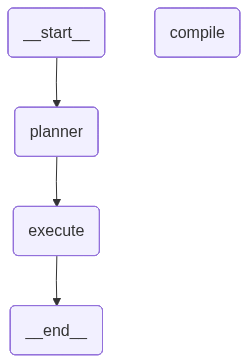

In [12]:
# Lancia l'agente
config = {"task": "Una lezione su Kant per studenti del 4° superiore"}
final_state = app.invoke(config)

# Mostra il risultato
print(f"Slide generate in: {final_state['html_path']}")
from IPython.display import IFrame
IFrame(src='./output.html', width='100%', height='500px')

steps=[PlanStep(title='Introduzione a Immanuel Kant', concept='Chi era Kant e perché la sua filosofia è rivoluzionaria. Breve biografia e contesto storico.'), PlanStep(title="L'Illuminismo e la 'Rivoluzione Copernicana' di Kant", concept='Il ruolo di Kant nel pensiero illuminista e la sua innovazione nel modo di concepire la conoscenza.'), PlanStep(title='La Critica della Ragion Pura: Come Conosciamo?', concept='Analisi delle facoltà conoscitive umane: sensibilità, intelletto e ragione. Il ruolo delle forme a priori.'), PlanStep(title='Fenomeno e Noumeno: I Limiti della Conoscenza', concept='La distinzione tra ciò che possiamo conoscere (fenomeno) e ciò che è inconoscibile (noumeno o cosa in sé).'), PlanStep(title="La Critica della Ragion Pratica: L'Etica del Dovere", concept="Introduzione alla filosofia morale di Kant e al concetto di 'volontà buona'."), PlanStep(title="L'Imperativo Categorico: La Legge Morale Universale", concept="Spiegazione delle formulazioni dell'imperativo catego